In [1]:
import xarray as xr
import numpy as np
import os

# --------------------------------------------------
# Paths
# --------------------------------------------------
base = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/data/snow_experiment/data/cids/1/backup_forcing/"
mswx = base + "MSWX/"
nldas = base + "NLDAS_on_HBmetgrid_float32/"

files = [
    "precip.nc",
    "tair.nc",
    "swdown.nc",
    "lwdown.nc",
    "spfh.nc",
    "wind.nc",
    "psurf.nc"
]

# --------------------------------------------------
# Helper
# --------------------------------------------------
def summarize_var(da):
    return {
        "shape": da.shape,
        "dtype": str(da.dtype),
        "min": float(np.nanmin(da.values)),
        "mean": float(np.nanmean(da.values)),
        "max": float(np.nanmax(da.values)),
        "std": float(np.nanstd(da.values)),
        "first_step_mean": float(np.nanmean(da.isel(t=0).values)),
        "last_step_mean": float(np.nanmean(da.isel(t=-1).values)),
    }

# --------------------------------------------------
# Compare each file
# --------------------------------------------------
for fname in files:
    print("\n" + "=" * 70)
    print("FILE:", fname)

    f_m = os.path.join(mswx, fname)
    f_n = os.path.join(nldas, fname)

    if not os.path.exists(f_m):
        print("Missing MSWX file:", f_m)
        continue
    if not os.path.exists(f_n):
        print("Missing NLDAS file:", f_n)
        continue

    ds_m = xr.open_dataset(f_m, decode_times=False)
    ds_n = xr.open_dataset(f_n, decode_times=False)

    var_m = list(ds_m.data_vars)[0]
    var_n = list(ds_n.data_vars)[0]

    da_m = ds_m[var_m]
    da_n = ds_n[var_n]

    print("\nMSWX variable:", var_m)
    print("MSWX attrs:", da_m.attrs)

    print("\nNLDAS variable:", var_n)
    print("NLDAS attrs:", da_n.attrs)

    sm = summarize_var(da_m)
    sn = summarize_var(da_n)

    print("\n--- BASIC STATS ---")
    print("MSWX :")
    for k, v in sm.items():
        print(f"  {k}: {v}")

    print("NLDAS:")
    for k, v in sn.items():
        print(f"  {k}: {v}")

    print("\n--- DIFFERENCE (NLDAS - MSWX) ---")
    print("mean diff:", sn["mean"] - sm["mean"])
    print("std diff :", sn["std"] - sm["std"])
    print("min diff :", sn["min"] - sm["min"])
    print("max diff :", sn["max"] - sm["max"])

    # same-grid direct difference
    if da_m.shape == da_n.shape:
        diff = da_n.values - da_m.values
        print("\n--- GRIDPOINT DIFFERENCE STATS ---")
        print("diff min :", float(np.nanmin(diff)))
        print("diff mean:", float(np.nanmean(diff)))
        print("diff max :", float(np.nanmax(diff)))
        print("diff std :", float(np.nanstd(diff)))

    # special check for precip total over full period
    if fname == "precip.nc":
        dt = 10800.0
        total_m = float(np.nanmean(da_m.values) * dt * da_m.shape[0])
        total_n = float(np.nanmean(da_n.values) * dt * da_n.shape[0])
        print("\n--- PRECIP TOTAL OVER PERIOD ---")
        print("MSWX total [mm]:", total_m)
        print("NLDAS total [mm]:", total_n)

    # special Celsius check for temperature
    if fname == "tair.nc":
        print("\n--- TAIR IN CELSIUS ---")
        print("MSWX mean [C]:", sm["mean"] - 273.15)
        print("NLDAS mean [C]:", sn["mean"] - 273.15)
        print("MSWX min  [C]:", sm["min"] - 273.15)
        print("NLDAS min [C]:", sn["min"] - 273.15)
        print("MSWX max  [C]:", sm["max"] - 273.15)
        print("NLDAS max [C]:", sn["max"] - 273.15)

    ds_m.close()
    ds_n.close()

print("\nDone.")


FILE: precip.nc

MSWX variable: precip
MSWX attrs: {'long_name': 'precip'}

NLDAS variable: precip
NLDAS attrs: {'long_name': 'precip', 'source': 'NLDAS Rainf aggregated from hourly to 3-hourly and interpolated to HydroBlocks grid', 'units': 'mm/s', 'conversion': 'Converted from 3-hour accumulated precipitation to mm/s'}

--- BASIC STATS ---
MSWX :
  shape: (32128, 16, 16)
  dtype: float32
  min: 0.0
  mean: 1.301888460147893e-05
  max: 0.0035821758210659027
  std: 5.496158337336965e-05
  first_step_mean: 0.0
  last_step_mean: 0.0
NLDAS:
  shape: (32128, 16, 16)
  dtype: float32
  min: -8.223874240207097e-20
  mean: 1.3008354471821804e-05
  max: 0.004958245437592268
  std: 7.052052387734875e-05
  first_step_mean: 0.0
  last_step_mean: 0.0

--- DIFFERENCE (NLDAS - MSWX) ---
mean diff: -1.0530129657126963e-08
std diff : 1.5558940503979102e-05
min diff : -8.223874240207097e-20
max diff : 0.0013760696165263653

--- GRIDPOINT DIFFERENCE STATS ---
diff min : -0.0035821758210659027
diff mean

In [2]:
import xarray as xr
import numpy as np

base = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/data/snow_experiment/data/cids/1/backup_forcing/"
mswx = base + "MSWX/"
nldas = base + "NLDAS_on_HBmetgrid_float32/"

start = np.datetime64("2016-01-01T00:00:00")
dt_hours = 3
nt = 32128
time = start + np.arange(nt) * np.timedelta64(dt_hours, "h")

winter_months = [12, 1, 2]
months = np.array([int(str(t)[5:7]) for t in time])
winter_idx = np.where(np.isin(months, winter_months))[0]

for fname in ["precip.nc", "tair.nc", "swdown.nc", "lwdown.nc"]:
    print("\n" + "=" * 60)
    print("WINTER CHECK:", fname)

    ds_m = xr.open_dataset(mswx + fname, decode_times=False)
    ds_n = xr.open_dataset(nldas + fname, decode_times=False)

    var_m = list(ds_m.data_vars)[0]
    var_n = list(ds_n.data_vars)[0]

    da_m = ds_m[var_m].isel(t=winter_idx)
    da_n = ds_n[var_n].isel(t=winter_idx)

    print("MSWX winter mean:", float(np.nanmean(da_m.values)))
    print("NLDAS winter mean:", float(np.nanmean(da_n.values)))
    print("Difference:", float(np.nanmean(da_n.values) - np.nanmean(da_m.values)))

    if fname == "tair.nc":
        print("MSWX winter mean [C]:", float(np.nanmean(da_m.values) - 273.15))
        print("NLDAS winter mean [C]:", float(np.nanmean(da_n.values) - 273.15))

    ds_m.close()
    ds_n.close()


WINTER CHECK: precip.nc
MSWX winter mean: 8.929132491175551e-06
NLDAS winter mean: 8.66613754624268e-06
Difference: -2.6299494493287057e-07

WINTER CHECK: tair.nc
MSWX winter mean: 273.2458190917969
NLDAS winter mean: 272.8493957519531
Difference: -0.39642333984375
MSWX winter mean [C]: 0.09581909179689774
NLDAS winter mean [C]: -0.30060424804685226

WINTER CHECK: swdown.nc
MSWX winter mean: 145.50376892089844
NLDAS winter mean: 134.52615356445312
Difference: -10.977615356445312

WINTER CHECK: lwdown.nc
MSWX winter mean: 228.310302734375
NLDAS winter mean: 212.85032653808594
Difference: -15.459976196289062


In [3]:
import xarray as xr
import numpy as np

# --------------------------------------------------
# Paths
# --------------------------------------------------
base = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/data/snow_experiment/data/cids/1/backup_forcing/"
mswx_file = base + "MSWX/precip.nc"
nldas_file = base + "NLDAS_on_HBmetgrid_float32/precip.nc"

# --------------------------------------------------
# Open
# --------------------------------------------------
ds_m = xr.open_dataset(mswx_file, decode_times=False)
ds_n = xr.open_dataset(nldas_file, decode_times=False)

lat_m = ds_m["lat"].values
lon_m = ds_m["lon"].values
lat_n = ds_n["lat"].values
lon_n = ds_n["lon"].values

print("MSWX lat shape:", lat_m.shape)
print("NLDAS lat shape:", lat_n.shape)
print("MSWX lon shape:", lon_m.shape)
print("NLDAS lon shape:", lon_n.shape)

print("\nMSWX lat first/last:", lat_m[0], lat_m[-1])
print("NLDAS lat first/last:", lat_n[0], lat_n[-1])

print("\nMSWX lon first/last:", lon_m[0], lon_m[-1])
print("NLDAS lon first/last:", lon_n[0], lon_n[-1])

print("\nMax abs lat diff:", float(np.max(np.abs(lat_n - lat_m))))
print("Max abs lon diff:", float(np.max(np.abs(lon_n - lon_m))))

print("\nAre lat arrays equal? ", np.allclose(lat_m, lat_n))
print("Are lon arrays equal? ", np.allclose(lon_m, lon_n))

print("\nMSWX lat values:")
print(lat_m)

print("\nNLDAS lat values:")
print(lat_n)

print("\nMSWX lon values:")
print(lon_m)

print("\nNLDAS lon values:")
print(lon_n)

ds_m.close()
ds_n.close()

MSWX lat shape: (16,)
NLDAS lat shape: (16,)
MSWX lon shape: (16,)
NLDAS lon shape: (16,)

MSWX lat first/last: 35.099998474121094 36.5999755859375
NLDAS lat first/last: 35.099998474121094 36.5999755859375

MSWX lon first/last: -106.39999771118164 -104.90002059936523
NLDAS lon first/last: -106.39999771118164 -104.90002059936523

Max abs lat diff: 0.0
Max abs lon diff: 0.0

Are lat arrays equal?  True
Are lon arrays equal?  True

MSWX lat values:
[35.09999847 35.19999695 35.29999542 35.3999939  35.49999237 35.59999084
 35.69998932 35.79998779 35.89998627 35.99998474 36.09998322 36.19998169
 36.29998016 36.39997864 36.49997711 36.59997559]

NLDAS lat values:
[35.09999847 35.19999695 35.29999542 35.3999939  35.49999237 35.59999084
 35.69998932 35.79998779 35.89998627 35.99998474 36.09998322 36.19998169
 36.29998016 36.39997864 36.49997711 36.59997559]

MSWX lon values:
[-106.39999771 -106.29999924 -106.20000076 -106.10000229 -106.00000381
 -105.90000534 -105.80000687 -105.70000839 -105.60

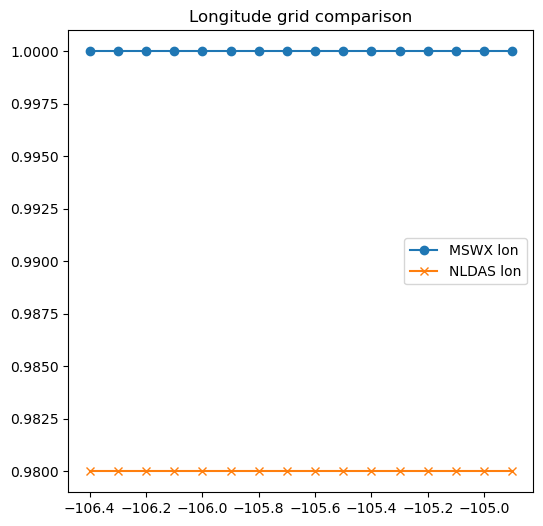

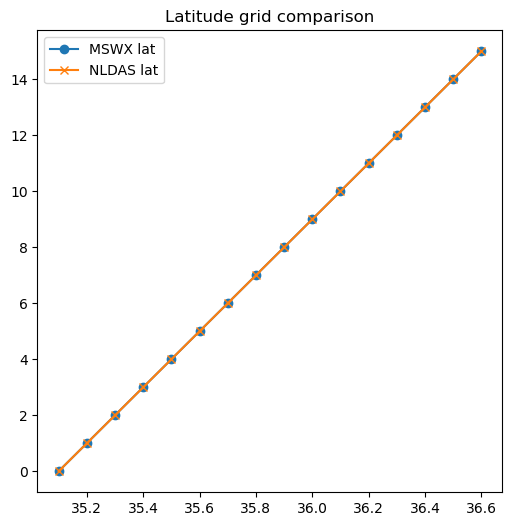

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.plot(lon_m, lat_m*0 + 1, 'o-', label='MSWX lon')
plt.plot(lon_n, lat_n*0 + 0.98, 'x-', label='NLDAS lon')
plt.legend()
plt.title("Longitude grid comparison")
plt.show()

plt.figure(figsize=(6,6))
plt.plot(lat_m, np.arange(len(lat_m)), 'o-', label='MSWX lat')
plt.plot(lat_n, np.arange(len(lat_n)), 'x-', label='NLDAS lat')
plt.legend()
plt.title("Latitude grid comparison")
plt.show()

Number of HRUs in SWE array: 1000
Min HRU id on raster: 0.0
Max HRU id on raster: 999.0
Number of valid raster HRUs: 1000


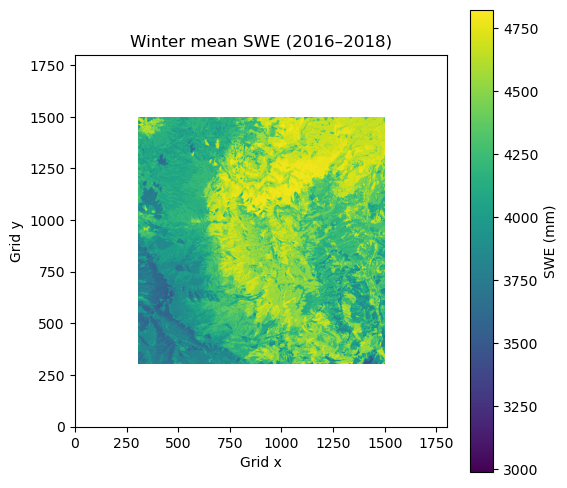

Winter SWE mean (mm): 3962.30615234375
Winter SWE min  (mm): 2991.138427734375
Winter SWE max  (mm): 4821.45458984375


In [8]:
import numpy as np
import netCDF4 as nc
import pandas as pd
import geospatialtools.gdal_tools as gdal_tools
import matplotlib.pyplot as plt

# ----------------------------
# Paths
# ----------------------------
path = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/NLDAS_3h_Snow_Project3_pp_downscale/"
swe_file = path + "output_data/1/2016-01-01.nc"

# ----------------------------
# Time (3-hourly)
# ----------------------------
fp = nc.Dataset(path + "1/input_file.nc")
time = fp.groups["meteorology"]["time"][:]   # hours since start
fp.close()

start = pd.Timestamp("2016-01-01 00:00:00")
times = start + pd.to_timedelta(time, unit="h")

winter_idx = np.where(pd.Series(times).dt.month.isin([12, 1, 2]))[0]

# ----------------------------
# Read HRU raster
# ----------------------------
hrus = gdal_tools.read_raster(path + "postprocess/hrus.vrt").astype(float)

# mask nodata
hrus[hrus < 0] = np.nan

# ----------------------------
# Read SWE
# ----------------------------
ds = nc.Dataset(swe_file)
swe = ds.groups["data"]["swe"][:]   # (time, hru)
ds.close()

# ----------------------------
# Winter mean SWE by HRU
# ----------------------------
swe_winter = np.nanmean(swe[winter_idx, :], axis=0)

print("Number of HRUs in SWE array:", swe_winter.shape[0])

# ----------------------------
# Map HRU -> grid
# ----------------------------
tmp = np.full(hrus.shape, np.nan)

unique_hrus = np.unique(hrus[~np.isnan(hrus)]).astype(int)

# keep only valid HRU ids
valid_hrus = unique_hrus[(unique_hrus >= 0) & (unique_hrus < swe_winter.shape[0])]

print("Min HRU id on raster:", np.nanmin(hrus))
print("Max HRU id on raster:", np.nanmax(hrus))
print("Number of valid raster HRUs:", len(valid_hrus))

for h in valid_hrus:
    tmp[hrus == h] = swe_winter[h]

# ----------------------------
# Plot
# ----------------------------
plt.figure(figsize=(6, 6))
plt.imshow(tmp, origin="lower")
plt.colorbar(label="SWE (mm)")
plt.title("Winter mean SWE (2016–2018)")
plt.xlabel("Grid x")
plt.ylabel("Grid y")
plt.show()

print("Winter SWE mean (mm):", float(np.nanmean(swe_winter)))
print("Winter SWE min  (mm):", float(np.nanmin(swe_winter)))
print("Winter SWE max  (mm):", float(np.nanmax(swe_winter)))